In [1]:
# load packages
import numpy as np 
import scipy.io
from scipy.io   import  loadmat
import pandas as pd
import os
import matplotlib.pyplot as plt #import matplotlib as plt
from scipy.optimize import curve_fit 
import seaborn as sns #import mat73
import pickle as pkl
from datetime import datetime
from itertools import chain
from scipy.optimize import curve_fit

In [2]:
from pathlib import Path
MainDir = Path.home() / "Desktop" / "Visual_Plasticty_Pipeline" / "Pipeline Processed Outputs" / "Cleaned_Local_RMS_Data"
os.chdir(MainDir) # change old dir, to this dir
d = os.listdir(MainDir) # list files in dir
print(f'Avilable Files to choose from: {len(d)}')
print(f'Files on hand: {d}')

Avilable Files to choose from: 3
Files on hand: ['rms_normalized_local_contrast_sweep_20260408_121516.mat', 'rms_normalized_local_contrast_sweep_20250918_160924.mat', 'rms_normalized_local_contrast_sweep_20260408_125433.mat']


In [3]:
FileN = d[0]#d[1] # choose one            
file_path1 = os.path.join(MainDir, FileN) # join paths and prep 2 load
print('Current WD:',file_path1) # does path exist ... ?
print('Does File #1 Exist?',os.path.exists(file_path1)) # yes or no

Current WD: /Users/patricia.naomi/Desktop/Visual_Plasticty_Pipeline/Pipeline Processed Outputs/Cleaned_Local_RMS_Data/rms_normalized_local_contrast_sweep_20260408_121516.mat
Does File #1 Exist? True


In [4]:
df = scipy.io.loadmat(file_path1) # RCA F1 File
print(df.keys())

dict_keys(['__header__', '__version__', '__globals__', 'F1_CleanData', 'F2_CleanData', 'Files_pSubj', 'Attn_Condition_pFile', 'TotFiles_pSubj', 'SessionOrder', 'Subj_ID'])


In [5]:
f1_data = df['F1_CleanData']
f2_data = df['F2_CleanData']

x = df['Files_pSubj'][0]
y = df['Attn_Condition_pFile'][0]
z = df['TotFiles_pSubj'][0]
t = df['SessionOrder'][0]

# new add ons 
NL_NumberID = df['Subj_ID'][0]
# gs_Bool = df['GoodSignalQualSubs']
# Identified_BadSubjs = df['IdentifiedBadSubjNums']
# BadEEG_Data = df['BadEEGBool']

In [6]:
print(NL_NumberID)
print(len(NL_NumberID))

[  2651   2652   2653   2654   2655   2657   2658   2659   2660   2661
   2663   2664   2665   2666   2667   2668   2669   2670   2672   2674
   2676   2677   2678   2695   2696   2697   2708   2715   2716   2726
   2727   2728   2733   2734   2737 345202 345215 345216]
38


In [7]:
print(x) # subject files belonging to 1 person
print(y) # attention condition bool [1 == attnL, 0 == attnR]
print(z) # Day X per subect - this array lyk how many sessions 1 subj completed and what day it was
print(t) # 0 == 1st session, 2 == 2nd session
print()
print(NL_NumberID) # all subjs

[ 0  0  1  1  2  2  3  3  4  4  5  5  6  6  7  7  8  9  9 10 10 11 11 12
 12 13 13 14 14 15 15 16 16 17 17 18 18 19 19 20 21 21 22 23 23 24 24 25
 25 26 27 28 29 30 31 31 32 33 34 35 35 36 36 37 37]
[1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 1 0 0 0 1 0 1 0 1 0 1 0 1 0 0 1 0 1 1 0
 1 0 0 1 0 0 1 0 0 1 1 0 1 1 1 0 1 1 0 1 1 1 1 0 1 0 0 1]
[1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2
 1 2 1 1 2 1 1 2 1 2 1 2 1 1 1 1 1 1 2 1 1 1 1 2 1 2 1 2]
[1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 1 2 1 2 2 1
 1 2 1 2 1 1 2 1 1 2 1 2 1 1 1 1 1 2 1 1 1 1 1 2 1 2 2 1]

[  2651   2652   2653   2654   2655   2657   2658   2659   2660   2661
   2663   2664   2665   2666   2667   2668   2669   2670   2672   2674
   2676   2677   2678   2695   2696   2697   2708   2715   2716   2726
   2727   2728   2733   2734   2737 345202 345215 345216]


In [8]:
unique_ids, counts = np.unique(x, return_counts=True)
print(unique_ids)

# Step 2: Filter for subject IDs that appear only once
single_session_ids = unique_ids[counts == 2]

print((single_session_ids))
print(len(single_session_ids))

print(NL_NumberID[single_session_ids])

#BadSubjs = [2653, 2654,2660,2665,2670,2672, 2654,2665,2667,2672]


[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37]
[ 0  1  2  3  4  5  6  7  9 10 11 12 13 14 15 16 17 18 19 21 23 24 25 31
 35 36 37]
27
[  2651   2652   2653   2654   2655   2657   2658   2659   2661   2663
   2664   2665   2666   2667   2668   2669   2670   2672   2674   2677
   2695   2696   2697   2728 345202 345215 345216]


In [9]:
print((f1_data.shape))
[Files, timeBlocks, NumBins] = f1_data.shape

(65, 2, 6)


In [10]:
NumSubs = ((int(np.max(x)))) +1
print(f'A total of {NumSubs + 1} subjs will be processed for analysis')

A total of 39 subjs will be processed for analysis


1
(38, 2, 6)
NumSubjs: 38, NumObs Measure: 6.164414002968976
2
(27, 2, 6)
NumSubjs: 27, NumObs Measure: 5.196152422706632


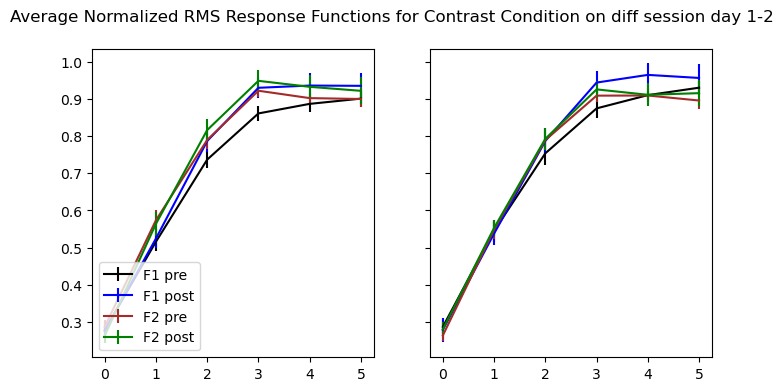

In [11]:
fig,axs = plt.subplots(1,2,figsize = ((8,4)), sharey = True)
plt.suptitle(f'Average Normalized RMS Response Functions for Contrast Condition on diff session day 1-2')
MaxSessions = 2

for sD in range(MaxSessions):
    SessionDay = sD+1
    print(SessionDay)

    DayX_Data1 = f1_data[z == SessionDay,:,:]
    dataDims = np.shape(DayX_Data1)
    print(DayX_Data1.shape)
    dataStandErrMeans1 = np.std(DayX_Data1,axis = 0) / np.sqrt(int(dataDims[0]))
    dataMeans1 = np.nanmean(DayX_Data1,axis = 0)

    DayX_Data2 = f2_data[z == SessionDay,:,:]
    dataStandErrMeans2 = np.std(DayX_Data2,axis = 0) / np.sqrt(int(dataDims[0]))
    dataMeans2 = np.nanmean(DayX_Data2,axis = 0)

    print(f'NumSubjs: {dataDims[0]}, NumObs Measure: {np.sqrt(int(dataDims[0]))}')
    axs[sD].errorbar(np.arange(0,NumBins,1),dataMeans1[0,:], yerr = dataStandErrMeans1[0,:], label = 'F1 pre', color = 'black')
    axs[sD].errorbar(np.arange(0,NumBins,1),dataMeans1[1,:], yerr = dataStandErrMeans1[1,:], label = 'F1 post', color = 'blue')

    axs[sD].errorbar(np.arange(0,NumBins,1),dataMeans2[0,:], yerr = dataStandErrMeans2[0,:], label = 'F2 pre', color = 'brown')
    axs[sD].errorbar(np.arange(0,NumBins,1),dataMeans2[1,:], yerr = dataStandErrMeans2[1,:], label = 'F2 post', color = 'green')

axs[0].legend(loc = 'lower left', fontsize = 10)

In [12]:
contrast_location = [1, 2.5, 6.3, 15.8, 39.8, 100]

(38, 2, 6)
(27, 2, 6)


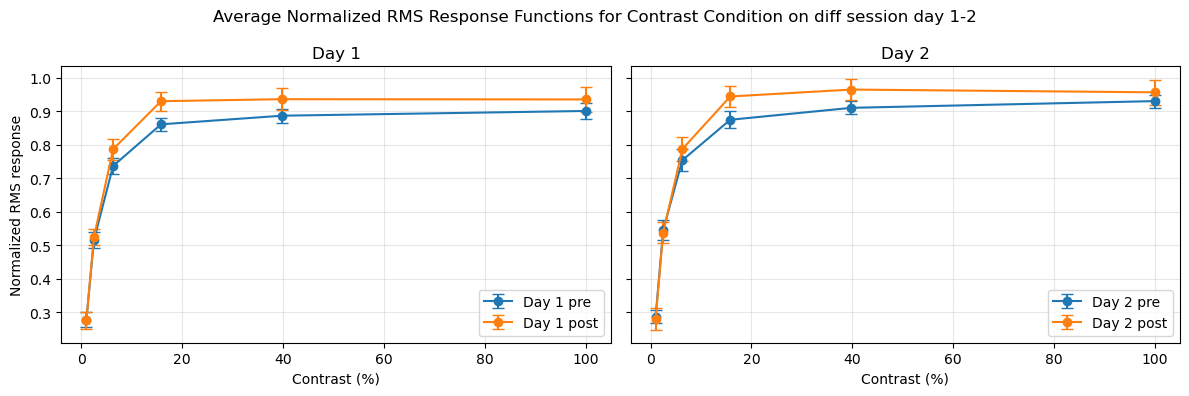

In [13]:
fig,axs = plt.subplots(1,2,figsize = ((12,4)), sharey = True)
plt.suptitle(f'Average Normalized RMS Response Functions for Contrast Condition on diff session day 1-2')
MaxSessions = 2

label = ['pre', 'post']

for sD in range(MaxSessions):
    SessionDay = sD+1

    DayX_Data1 = f1_data[z == SessionDay,:,:] # [day x prepost x contrast]
    print(DayX_Data1.shape)

    for pp in range(2): 
        y_pre = np.nanmean(DayX_Data1[:, pp, :], axis=0)  
        n_pre = np.sum(~np.isnan(DayX_Data1[:, pp, :]), axis=0)
        sem_pre = np.nanstd(DayX_Data1[:, pp, :], axis=0, ddof=1) / np.sqrt(np.clip(n_pre, 1, None))

        axs[sD].errorbar(contrast_location, y_pre, yerr=sem_pre, fmt='o-', capsize=4, label=f'Day {SessionDay} {label[pp]}')
        axs[sD].legend()


        axs[sD].set_title(f'Day {SessionDay}')
        axs[sD].set_xlabel('Contrast (%)')
        if sD == 0:
            axs[sD].set_ylabel('Normalized RMS response')
        axs[sD].legend()
        axs[sD].grid(True, alpha=0.3)

    plt.tight_layout()


(21, 2, 6)
NumSubjs: 21, NumObs Measure: 4.58257569495584
(13, 2, 6)
NumSubjs: 13, NumObs Measure: 3.605551275463989


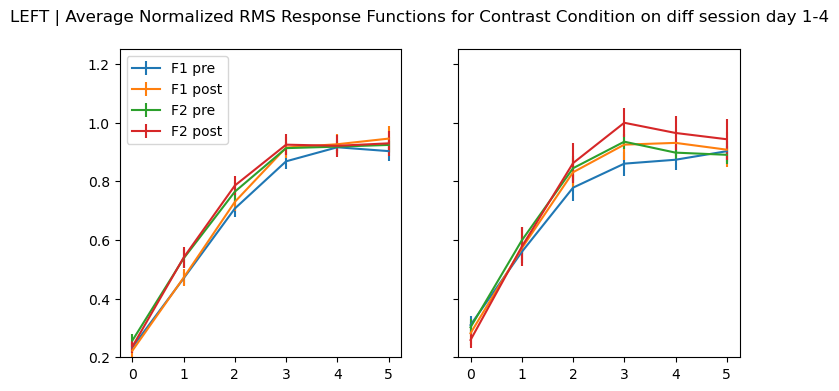

In [14]:
fig,axs = plt.subplots(1,2,figsize = ((8,4)), sharey = True)
plt.suptitle(f'LEFT | Average Normalized RMS Response Functions for Contrast Condition on diff session day 1-4')
MaxSessions = 2

for sD in range(MaxSessions):
    #SessionDay = sD+1

    #DayX_Data1 = f1_data[(z == sD+1)&(y == 1),:,:] # 
    DayX_Data1 = f1_data[(t == sD+1)&(y == 1),:,:] # 
    dataDims = np.shape(DayX_Data1)
    print(DayX_Data1.shape)
    dataStandErrMeans1 = np.std(DayX_Data1,axis = 0) / np.sqrt(int(dataDims[0]))
    dataMeans1 = np.nanmean(DayX_Data1,axis = 0)

    DayX_Data2 = f2_data[(t == sD+1)&(y == 1),:,:]
    dataStandErrMeans2 = np.std(DayX_Data2,axis = 0) / np.sqrt(int(dataDims[0]))
    dataMeans2 = np.nanmean(DayX_Data2,axis = 0)

    print(f'NumSubjs: {dataDims[0]}, NumObs Measure: {np.sqrt(int(dataDims[0]))}')

    axs[sD].errorbar(np.arange(0,NumBins,1),dataMeans1[0,:], yerr = dataStandErrMeans1[0,:], label = 'F1 pre')
    axs[sD].errorbar(np.arange(0,NumBins,1),dataMeans1[1,:], yerr = dataStandErrMeans1[1,:], label = 'F1 post')

    axs[sD].errorbar(np.arange(0,NumBins,1),dataMeans2[0,:], yerr = dataStandErrMeans2[0,:], label = 'F2 pre')
    axs[sD].errorbar(np.arange(0,NumBins,1),dataMeans2[1,:], yerr = dataStandErrMeans2[1,:], label = 'F2 post')

    # axs[sD].errorbar(np.arange(0,NumBins,1),dataMeans1[0,:],  label = 'F1 pre')
    # axs[sD].errorbar(np.arange(0,NumBins,1),dataMeans1[1,:], label = 'F1 post')

    # axs[sD].errorbar(np.arange(0,NumBins,1),dataMeans2[0,:], label = 'F2 pre')
    # axs[sD].errorbar(np.arange(0,NumBins,1),dataMeans2[1,:], label = 'F2 post')

    axs[sD].set_ylim(0.2, 1.25)

axs[0].legend(loc = 'upper left')

(17, 2, 6)
NumSubjs: 17, NumObs Measure: 4.123105625617661
(14, 2, 6)
NumSubjs: 14, NumObs Measure: 3.7416573867739413


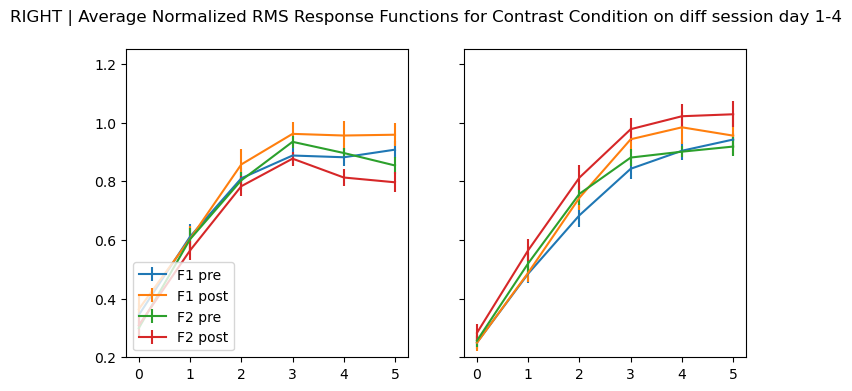

In [15]:
fig,axs = plt.subplots(1,2,figsize = ((8,4)), sharey = True)
plt.suptitle(f'RIGHT | Average Normalized RMS Response Functions for Contrast Condition on diff session day 1-4')
MaxSessions = 2

for sD in range(MaxSessions):

    DayX_Data1 = f1_data[(t== sD+1) &(y == 0),:,:]
    dataDims = np.shape(DayX_Data1)
    print(DayX_Data1.shape)
    dataStandErrMeans1 = np.std(DayX_Data1,axis = 0) / np.sqrt(int(dataDims[0]))
    dataMeans1 = np.nanmean(DayX_Data1,axis = 0)

    DayX_Data2 = f2_data[(t == sD+1)&(y == 0),:,:]
    dataStandErrMeans2 = np.std(DayX_Data2,axis = 0) / np.sqrt(int(dataDims[0]))
    dataMeans2 = np.nanmean(DayX_Data2,axis = 0)

    print(f'NumSubjs: {dataDims[0]}, NumObs Measure: {np.sqrt(int(dataDims[0]))}')

    axs[sD].errorbar(np.arange(0,NumBins,1),dataMeans1[0,:], yerr = dataStandErrMeans1[0,:], label = 'F1 pre')
    axs[sD].errorbar(np.arange(0,NumBins,1),dataMeans1[1,:], yerr = dataStandErrMeans1[1,:], label = 'F1 post')

    axs[sD].errorbar(np.arange(0,NumBins,1),dataMeans2[0,:], yerr = dataStandErrMeans2[0,:], label = 'F2 pre')
    axs[sD].errorbar(np.arange(0,NumBins,1),dataMeans2[1,:], yerr = dataStandErrMeans2[1,:], label = 'F2 post')

    # axs[sD].errorbar(np.arange(0,NumBins,1),dataMeans1[0,:],  label = 'F1 pre')
    # axs[sD].errorbar(np.arange(0,NumBins,1),dataMeans1[1,:],  label = 'F1 post')

    # axs[sD].errorbar(np.arange(0,NumBins,1),dataMeans2[0,:],  label = 'F2 pre')
    # axs[sD].errorbar(np.arange(0,NumBins,1),dataMeans2[1,:],  label = 'F2 post')

    axs[sD].set_ylim(0.2, 1.25)

axs[0].legend(loc = 'lower left')

In [16]:
print(f1_data[0,:,:,])

[[0.14427458 0.33860257 0.57486198 0.82984809 1.         0.94462908]
 [0.09788009 0.28747832 0.57402957 0.79932049 0.95482245 0.88110277]]


In [17]:
def Make_DataFrames(NumBins, NumSubj, Data, SubjBool, AttnBool, DayBool, HemiInd, NL_ID):
    # Extract subject-specific data and conditions
    dataImport = Data[SubjBool == NumSubj]
    AttnCond = AttnBool[SubjBool == NumSubj]
    DayCond = DayBool[SubjBool == NumSubj]

    TotRows = NumBins * dataImport.shape[0]  # Total rows = sessions * bins

    # Create metadata arrays
    HemifieldArray = np.full(TotRows, HemiInd)               # Hemifield identifier
    Subj_ID = np.full(TotRows, NumSubj)                      # Subject ID
    NorciaLabNum = np.full(TotRows, NL_ID)                   # Lab ID or identifier
    Attention_Array = np.repeat(AttnCond, NumBins)           # Attention condition per bin
    SessionDay_Array = np.repeat(DayCond, NumBins)           # Session day labels per bin
    ContrastArray = np.tile(np.arange(NumBins), dataImport.shape[0])  # Bin indices repeated for each session

    # Extract pre and post response values
    preData = dataImport[:, 0, :].reshape(-1)  # Pre-condition RMS data
    postData = dataImport[:, 1, :].reshape(-1)  # Post-condition RMS data

    # Stack all data into a final subject matrix [8 x TotRows]
    # Row mapping:
    # 0 - Subject ID
    # 1 - Session Day
    # 2 - Attention Condition
    # 3 - Hemifield
    # 4 - Contrast Bin Index
    # 5 - Pre-response
    # 6 - Post-response
    # 7 - Lab Identifier
    SingleSubj_DataFrame = np.vstack([
        Subj_ID,
        SessionDay_Array,
        Attention_Array,
        HemifieldArray,
        ContrastArray,
        preData,
        postData,
        NorciaLabNum
    ])

    return SingleSubj_DataFrame, TotRows

In [18]:
LeftHemiDataFrames = {}
RightHemiDataFrames = {}

numRows_pSubj = []

for nS in range(NumSubs): 
    LeftHemiDataFrames[f'DF_{nS}'], Rows_p_DF = Make_DataFrames(NumBins, NumSubj = nS, Data = f1_data, SubjBool = x, AttnBool = y,DayBool = t, HemiInd = 0,NL_ID = NL_NumberID[nS])
    numRows_pSubj.append(Rows_p_DF)
    RightHemiDataFrames[f'DF_{nS}'],_ = Make_DataFrames(NumBins, NumSubj = nS, Data = f2_data, SubjBool = x, AttnBool = y,DayBool = t, HemiInd = 1,NL_ID = NL_NumberID[nS])

In [19]:
print(np.unique(numRows_pSubj, return_counts = True))

(array([ 6, 12]), array([11, 27]))


In [20]:
RowSpace_pSubj = np.array(numRows_pSubj) # number of rows per subject - depends on eeg sess. avilable

leftHemi_df = np.zeros((8,np.sum(RowSpace_pSubj)))
righthemi_df = np.copy(leftHemi_df)

print(leftHemi_df.shape)
print(righthemi_df.shape)

(8, 390)
(8, 390)


In [21]:
rowSpaceCounter = 0
for df_Files in range(NumSubs):
    df_mat_leftH = LeftHemiDataFrames[f'DF_{df_Files}']
    df_mat_rightH = RightHemiDataFrames[f'DF_{df_Files}']

    rowsPresent = int(df_mat_leftH.shape[1])
    start_rowInd = rowSpaceCounter
    rowSpaceCounter = rowSpaceCounter + rowsPresent
    # print(start_rowInd,rowSpaceCounter)

    leftHemi_df[:,start_rowInd:rowSpaceCounter] = df_mat_leftH
    righthemi_df[:,start_rowInd:rowSpaceCounter] = df_mat_rightH

In [22]:
CleanSignalData = np.array(np.concatenate((leftHemi_df, righthemi_df), axis = 1))
headers = ['Sub_ID','Sess_Day', 'Attn_Dep','Hemifield','Sweep','Pre','Post','NL_ID']
DF_Out = pd.DataFrame(CleanSignalData.T, columns = headers) # add headers to mat

In [23]:
DF_Out

,Sub_ID,Sess_Day,Attn_Dep,Hemifield,Sweep,Pre,Post,NL_ID
0,0.0,1.0,1.0,0.0,0.0,0.144275,0.097880,2651.0
1,0.0,1.0,1.0,0.0,1.0,0.338603,0.287478,2651.0
2,0.0,1.0,1.0,0.0,2.0,0.574862,0.574030,2651.0
3,0.0,1.0,1.0,0.0,3.0,0.829848,0.799320,2651.0
4,0.0,1.0,1.0,0.0,4.0,1.000000,0.954822,2651.0
...,...,...,...,...,...,...,...,...
775,37.0,1.0,1.0,1.0,1.0,0.454614,0.414079,345216.0
776,37.0,1.0,1.0,1.0,2.0,0.637058,0.624473,345216.0
777,37.0,1.0,1.0,1.0,3.0,0.789352,0.836641,345216.0
778,37.0,1.0,1.0,1.0,4.0,0.843263,0.870025,345216.0


In [24]:
d_frameOut = DF_Out.astype(np.float64)
print(d_frameOut.shape)

(780, 8)


# **This section was made to export data that was obtained for Session Day 1 ONLY**

In [25]:
# Day1_DataOnly = DF_Out[DF_Out['Sess_Day'] == 0]

# d_frameOut = Day1_DataOnly.astype(np.float64)
print(d_frameOut.shape)

(780, 8)


In [26]:
# print([Day1_DataOnly['Sess_Day']])

In [27]:
FramesOut = {'CRF_RMS_Values': d_frameOut,
             'Headers': headers}


# FileOutName = 'Longitudinal_SSRP_DescriptiveTable_RMS_SpatFreq_LME_DF_RCA1'
FileOutName = 'LongitudinalSSRP_PreS1_Table_RMS_Contrast_CRF'
print(FileOutName)
dnt = datetime.now() # add date and time bc im wreckless when saving ..
fdnt = dnt.strftime("%Y%m%d_%H%M%S") # set the above as a string ...
FileName= f'{FileOutName}_{fdnt}.mat' 
CSV_FileN = f'{FileOutName}_{fdnt}.csv'
print(FileN)
print(CSV_FileN)


LongitudinalSSRP_PreS1_Table_RMS_Contrast_CRF
rms_normalized_local_contrast_sweep_20260408_121516.mat
LongitudinalSSRP_PreS1_Table_RMS_Contrast_CRF_20260408_143823.csv


In [28]:
def MakeNewFolder(folder_name):
    if not os.path.exists(folder_name):
        os.makedirs(folder_name)
        print(f'Folder {folder_name} created')
    else:
        print(f'Folder {folder_name} already exists')

In [29]:
from pathlib import Path
DataDirOut = Path.home() / "Desktop" / "Visual_Plasticty_Pipeline" / "Pipeline Processed Outputs"

os.chdir(DataDirOut)

folder_name = 'Spreadsheets'
MakeNewFolder(folder_name)

os.chdir(folder_name)

Folder Spreadsheets already exists


In [30]:
scipy.io.savemat(FileName, FramesOut)
panda_dataFrame = pd.DataFrame(FramesOut['CRF_RMS_Values'], columns=FramesOut['Headers'])
panda_dataFrame.to_csv(CSV_FileN, index = False)